In [2]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd


In [3]:
from tqdm import tqdm
import h5py

from multicam_tng.utils import convert_tng_mass, TNG_H

In [4]:
# hydro
subhalo_ids = []
stellar_mass = []
subhalo_mass_hydro = []

count = 0
for ii in tqdm(range(0, 448)):
    filename = f'../../data/tng100/fof_subhalo_tab_099.{ii}.hdf5'
    with h5py.File(filename, 'r') as f:

            

        if 'SubhaloMass' in f['Subhalo'].keys():
            for s in f['Subhalo']['SubhaloMass']:
                subhalo_ids.append(count)
                subhalo_mass_hydro.append(s)
                count+=1

            for s in f['Subhalo']['SubhaloMassInRadType'][:,4]: # 4 = star particles
                stellar_mass.append(s) 


subhalo_ids = np.array(subhalo_ids)
subhalo_mass = convert_tng_mass(np.array(subhalo_mass_hydro)) # log10(Msun / h)
stellar_mass = convert_tng_mass(np.array(stellar_mass)) # log10(Msun / h)
# group_mass = convert_tng_mass2(np.array(group_mass))
# hat_group_mass = convert_tng_mass2(np.array(hat_group_mass))

100%|██████████| 448/448 [00:06<00:00, 74.28it/s] 
/Users/imendoza/code/multicam-tng-mah/multicam_tng/utils.py:35: RuntimeWarning: divide by zero encountered in log10
  return np.where(gmass > 0, np.log10(gmass * 1e10 / TNG_H), 0)


In [5]:
smass = stellar_mass[stellar_mass > np.log10(1.4e6 * 100 / TNG_H)]

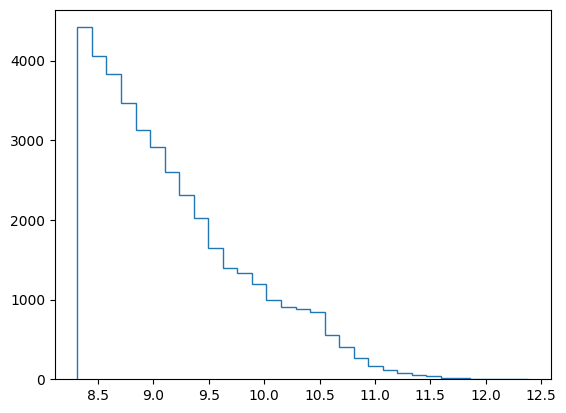

In [6]:
plt.hist(smass, histtype='step', bins=31);

In [ ]:
smass.min()

np.float32(8.315309)

In [35]:
# the SMF is defined as the number density of galaxies in bins of stellar mass
x1 = 8.5
x2 = 11.5
delta = 0.1
bins = np.arange(x1, x2, step=delta)
V_box = 110.7**3

nd = []
for ii in range(len(bins) - 1):
    b1 = bins[ii]
    b2 = bins[ii+1]
    cond1 = smass > b1 
    cond2 = smass < b2
    number_density = sum(cond1 & cond2) / V_box/ delta # box volume
    nd.append(number_density)

nd = np.array(nd)
x = (bins[1:] + bins[:-1]) /2

x.shape, nd.shape


((29,), (29,))

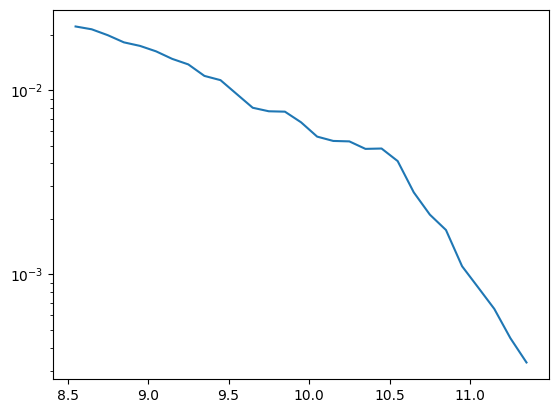

In [36]:
plt.semilogy(x,nd)

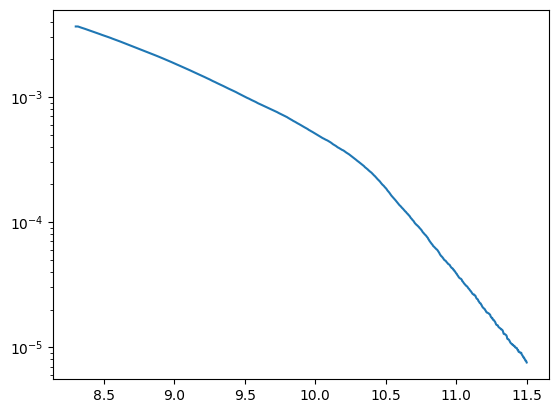

In [ ]:
# SMF

nh = np.array([sum(smass > b) for b in bins])
smf = nh /  len(smass) / 100 # box
smf /= smf.sum() # normalize

plt.semilogy(bins, smf)

# looks like what I see in the papers

In [9]:
bins

array([ 8.3   ,  8.3032,  8.3064, ..., 11.4936, 11.4968, 11.5   ],
      shape=(1001,))

In [13]:
smf.sum() # normalized

np.float64(0.9999999999999998)

In [ ]:
sigma = 0.2  # example

gaussian = np.exp(-0.5 * (bins/ sigma)**2)
gaussian /= np.sum(gaussian) * dx  # normalize as a PDF